# 🏋️ Notebook 03: Multimodal Model Training & Evaluation

**Objective:** Fine-tune the DenseNet-121 + Bio_ClinicalBERT fusion model on MedPix.

**Architecture:**
```
IMAGE (224×224×3) → DenseNet-121 → GAP → [1024-dim embedding]
                                                              \
         Concat [1792-dim] → Linear(512) → LayerNorm → ReLU → Linear(10)
                                                              /
TEXT (tokens × 256) → Bio_ClinicalBERT → [CLS] → [768-dim embedding]
```

**Sections:**
1. Setup model + optimizer + scheduler
2. Compute class weights for imbalance
3. Training loop with AMP (mixed precision)
4. Training curves visualization
5. Comprehensive evaluation on test set
6. Confusion matrix + AUC-ROC curves
7. Save evaluation report

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    matthews_corrcoef, roc_auc_score, roc_curve, auc
)
import torchvision.transforms as T

import config
from src.training.multimodal_predictor import MultimodalClinicalPredictor, MultimodalDataset

torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'Device: {DEVICE} | AMP: {USE_AMP}')

# Check CUDA VRAM if available
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {vram_gb:.1f} GB')
    if vram_gb < 6:
        print('⚠️  Low VRAM detected (< 6 GB). Freezing DenseNet base + BERT base for speed.')
        FREEZE_BASES = True
    else:
        FREEZE_BASES = False
else:
    FREEZE_BASES = True  # CPU mode: freeze to speed up training
    print('⚠️  CPU mode — freezing base layers. Training will be slow but functional.')

Device: cuda | AMP: True
GPU: NVIDIA GeForce GTX 1650 | VRAM: 4.3 GB
⚠️  Low VRAM detected (< 6 GB). Freezing DenseNet base + BERT base for speed.


## 1️⃣ Initialize Model

In [2]:
hf_token = config.HF_TOKEN if config.HF_TOKEN != 'YOUR_HF_TOKEN_HERE' else None
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_ENCODER_MODEL, token=hf_token)

model = MultimodalClinicalPredictor(
    num_classes=config.NUM_CLASSES,
    text_model_name=config.TEXT_ENCODER_MODEL,
    hidden_dim=config.FUSION_HIDDEN_DIM,
    dropout_rate=config.DROPOUT_RATE,
    freeze_image_base=FREEZE_BASES,
    freeze_text_base=FREEZE_BASES,
).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     116,316,293
Trainable parameters: 17,978,629 (15.5%)


## 2️⃣ DataLoaders + Class Weights

In [3]:
df_train = pd.read_csv('../data/processed/train.csv')
df_val   = pd.read_csv('../data/processed/val.csv')
df_test  = pd.read_csv('../data/processed/test.csv')

# Image transforms (import from preprocessing)
train_transform = T.Compose([
    T.Resize((config.IMAGE_SIZE[0] + 24, config.IMAGE_SIZE[1] + 24)),
    T.RandomCrop(config.IMAGE_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])
val_transform = T.Compose([
    T.Resize(config.IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

train_ds = MultimodalDataset(df_train, train_transform, tokenizer, config.MAX_TEXT_LENGTH)
val_ds   = MultimodalDataset(df_val,   val_transform,   tokenizer, config.MAX_TEXT_LENGTH)
test_ds  = MultimodalDataset(df_test,  val_transform,   tokenizer, config.MAX_TEXT_LENGTH)

train_loader = torch.utils.data.DataLoader(train_ds, config.BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   config.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_ds,  config.BATCH_SIZE, shuffle=False, num_workers=0)

# Compute class weights for imbalanced CrossEntropyLoss
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label'].values,
)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', {config.CLASS_NAMES[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor, label_smoothing=0.1)
print('\n✅ DataLoaders and loss function ready.')

Class weights: {'Neoplasm': '0.746', 'Vascular_Trauma': '1.128', 'Infection_Inflammatory': '2.704', 'Other': '0.775', 'Clinical Sign': '0.898'}

✅ DataLoaders and loss function ready.


## 3️⃣ Optimizer + Scheduler

In [4]:
# Unfreeze Layers for Differential Learning Rates
for param in model.text_encoder.bert.pooler.parameters():
    param.requires_grad = True

for layer in model.text_encoder.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

for param in model.image_encoder.features.denseblock4.parameters():
    param.requires_grad = True

if hasattr(model.image_encoder, 'classifier'):
    for param in model.image_encoder.classifier.parameters():
        param.requires_grad = True

optimizer_params = [
    {'params': model.fusion_head.parameters(), 'lr': 3e-3, 'weight_decay': 1e-2},
    {'params': model.image_encoder.features.denseblock4.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.text_encoder.bert.encoder.layer[-2:].parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.text_encoder.bert.pooler.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
]
if hasattr(model.image_encoder, 'classifier'):
    optimizer_params.append({'params': model.image_encoder.classifier.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4})
    
optimizer = torch.optim.AdamW(optimizer_params)

# Linear warmup + linear decay scheduler
total_steps  = len(train_loader) * config.EPOCHS
warmup_steps = int(total_steps * 0.1)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print(f'Total training steps:  {total_steps}')
print(f'Warmup steps:          {warmup_steps}')
print(f'Epochs:                {config.EPOCHS}')

Total training steps:  4475
Warmup steps:          447
Epochs:                25


## 4️⃣ Training Loop

In [5]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            return False  # do not stop
        self.counter += 1
        return self.counter >= self.patience

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stopper = EarlyStopping(patience=7)

for epoch in range(1, config.EPOCHS + 1):
    # ── TRAIN ──────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{config.EPOCHS} [Train]', leave=False):
        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images, input_ids, attention_mask)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=1.0
        )
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=-1)
        train_correct += (preds == labels).sum().item()
        train_total   += len(labels)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    # ── VALIDATE ────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{config.EPOCHS} [Val]', leave=False):
            images         = batch['image'].to(DEVICE)
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(images, input_ids, attention_mask)
                loss   = criterion(logits, labels)

            val_loss  += loss.item() * len(labels)
            preds = logits.argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total   += len(labels)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{config.EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | LR: {current_lr:.2e}')

    # ── Checkpoint & Early Stopping ──────────────────────────────────────────
    if early_stopper(val_loss):
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break
    else:
        if early_stopper.counter == 0:
            torch.save(model.state_dict(), config.BEST_MODEL_PATH)
            print(f'  ✅ Best model saved (val_loss={val_loss:.4f})')

print('\n=== Training Complete ===')

Epoch 1/25 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 01/25 | Train Loss: 1.6994 | Train Acc: 0.256 | Val Loss: 1.5607 | Val Acc: 0.364 | LR: 1.20e-03
  ✅ Best model saved (val_loss=1.5607)


Epoch 2/25 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 2/25 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

...

Epoch 24/25 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 0.8898 | Train Acc: 0.788 | Val Loss: 1.0898 | Val Acc: 0.675 | LR: 1.33e-04


Epoch 25/25 [Train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 0.8923 | Train Acc: 0.788 | Val Loss: 1.0735 | Val Acc: 0.675 | LR: 0.00e+00

=== Training Complete ===


## 5️⃣ Training Curves

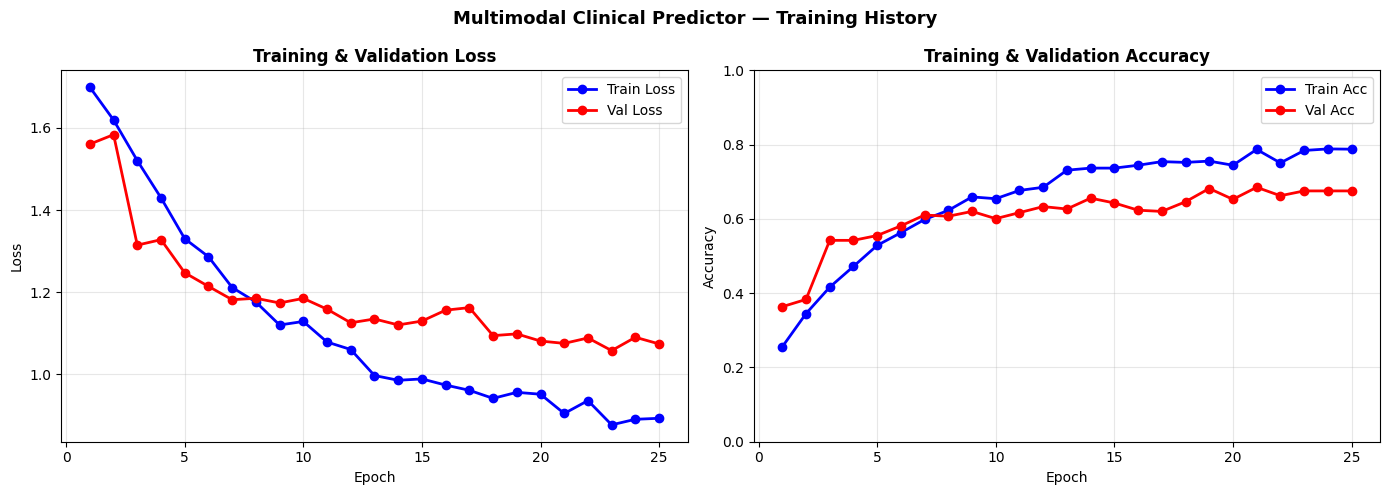

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss curve
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_ran, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.suptitle('Multimodal Clinical Predictor — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 6️⃣ Test Set Evaluation: Full Metrics Suite

In [7]:
# Load best checkpoint for evaluation
model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating on test set'):
        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        logits = model(images, input_ids, attention_mask)
        probs  = F.softmax(logits, dim=-1)
        preds  = probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Print classification report ─────────────────────────────────────────
print('=== CLASSIFICATION REPORT (Test Set) ===')
print(classification_report(
    all_labels, all_preds,
    target_names=config.CLASS_NAMES,
    digits=4,
))

# ── Additional metrics ──────────────────────────────────────────────────
kappa = cohen_kappa_score(all_labels, all_preds)
mcc   = matthews_corrcoef(all_labels, all_preds)
print(f"Cohen's Kappa:                {kappa:.4f}")
print(f'Matthews Corr. Coefficient:  {mcc:.4f}')

# AUC-ROC (macro OvR)
try:
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    print(f'AUC-ROC (macro OvR):         {auc_score:.4f}')
except Exception as e:
    auc_score = None
    print(f'AUC-ROC: Could not compute ({e})')

Evaluating on test set:   0%|          | 0/39 [00:00<?, ?it/s]

=== CLASSIFICATION REPORT (Test Set) ===
                        precision    recall  f1-score   support

              Neoplasm     0.6977    0.7317    0.7143        82
       Vascular_Trauma     0.6818    0.8182    0.7438        55
Infection_Inflammatory     0.5862    0.7391    0.6538        23
                 Other     0.8113    0.5375    0.6466        80
         Clinical Sign     0.5405    0.5882    0.5634        68

              accuracy                         0.6656       308
             macro avg     0.6635    0.6830    0.6644       308
          weighted avg     0.6813    0.6656    0.6641       308

Cohen's Kappa:                0.5727
Matthews Corr. Coefficient:  0.5763
AUC-ROC (macro OvR):         0.9148


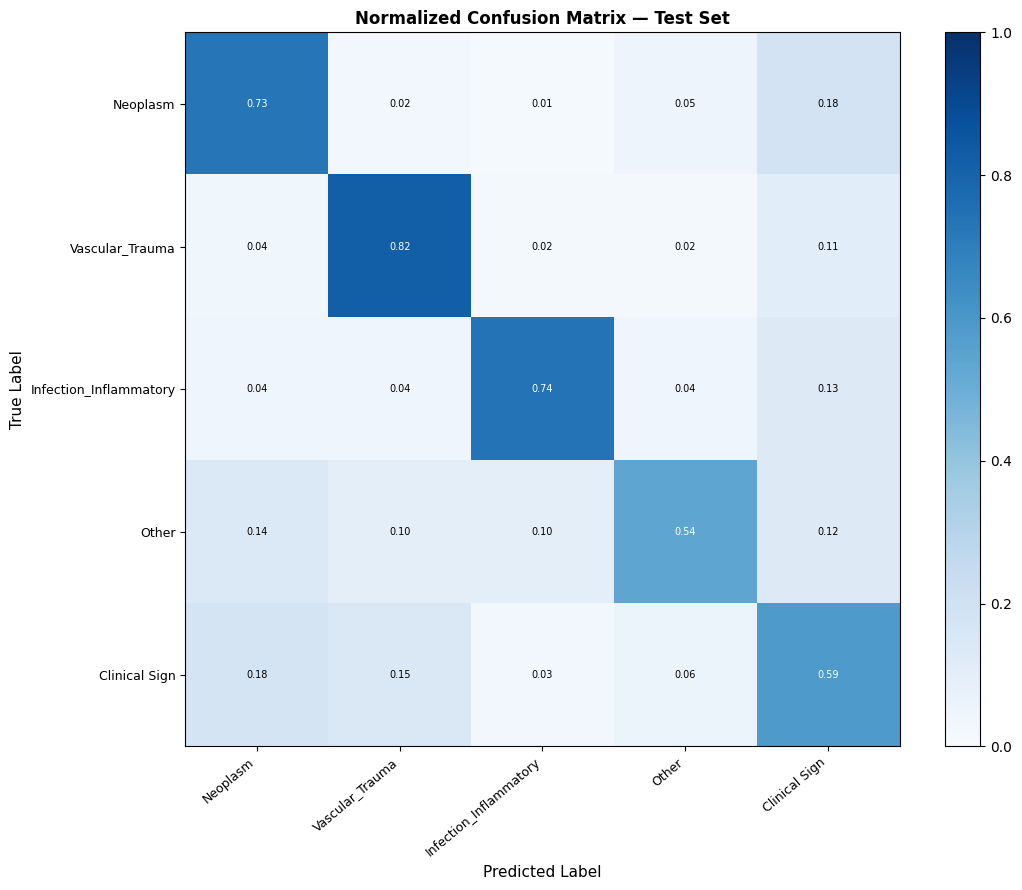

In [8]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(config.NUM_CLASSES))
ax.set_yticks(range(config.NUM_CLASSES))
ax.set_xticklabels(config.CLASS_NAMES, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(config.CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Normalized Confusion Matrix — Test Set', fontweight='bold', fontsize=12)

for i in range(config.NUM_CLASSES):
    for j in range(config.NUM_CLASSES):
        color = 'white' if cm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

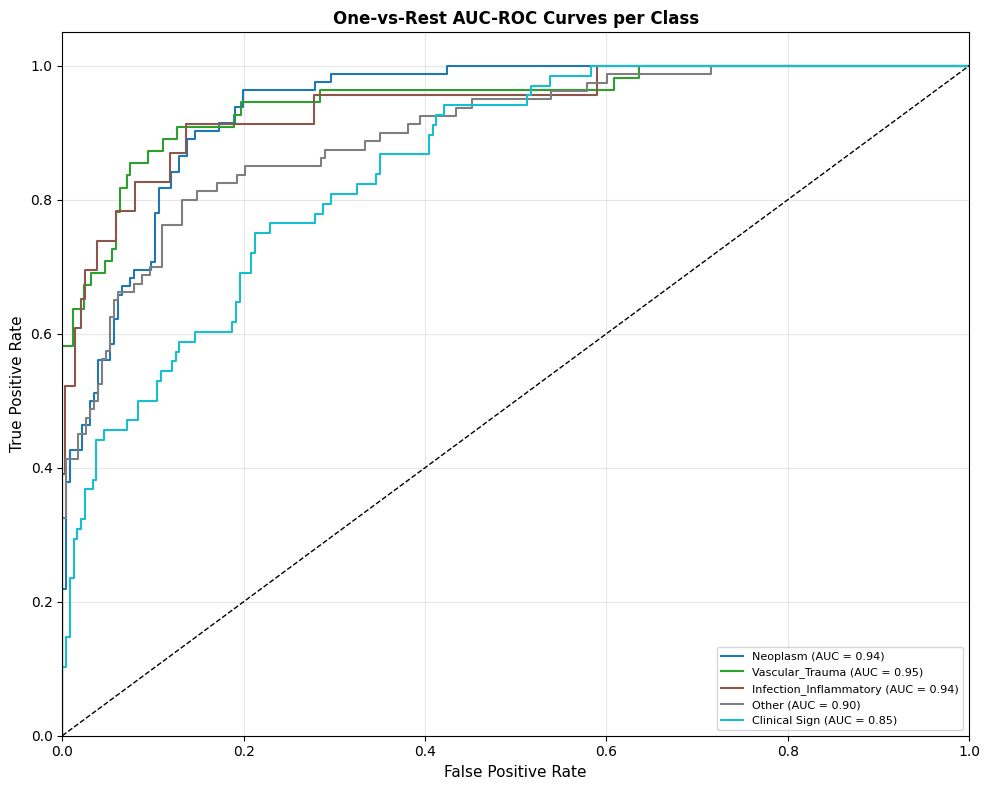

In [9]:
# ── AUC-ROC Curves per class ─────────────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=range(config.NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, config.NUM_CLASSES))

for i, (cls_name, color) in enumerate(zip(config.CLASS_NAMES, colors)):
    try:
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{cls_name} (AUC = {roc_auc:.2f})')
    except:
        pass

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('One-vs-Rest AUC-ROC Curves per Class', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7️⃣ Save Evaluation Report

In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

eval_report = {
    'model':          'MultimodalClinicalPredictor (DenseNet121 + BioClinicalBERT)',
    'dataset':        'MedPix',
    'test_samples':   int(len(all_labels)),
    'accuracy':       float(accuracy_score(all_labels, all_preds)),
    'f1_macro':       float(f1_score(all_labels, all_preds, average='macro',    zero_division=0)),
    'f1_weighted':    float(f1_score(all_labels, all_preds, average='weighted', zero_division=0)),
    'precision_macro': float(precision_score(all_labels, all_preds, average='macro',    zero_division=0)),
    'recall_macro':   float(recall_score(all_labels, all_preds, average='macro',    zero_division=0)),
    'auc_roc_macro':  float(auc_score) if auc_score else None,
    'cohen_kappa':    float(kappa),
    'mcc':            float(mcc),
    'class_names':    config.CLASS_NAMES,
    'history':        history,
}

with open(config.EVAL_REPORT_PATH, 'w') as f:
    json.dump(eval_report, f, indent=2)

print('=== EVALUATION SUMMARY ===')
for k, v in eval_report.items():
    if k not in ('history', 'class_names'):
        print(f'  {k:20s}: {v}')

print(f'\n✅ Evaluation report saved to: {config.EVAL_REPORT_PATH}')
print('Proceed to Notebook 04: Explainability (XAI).')

=== EVALUATION SUMMARY ===
  model               : MultimodalClinicalPredictor (DenseNet121 + BioClinicalBERT)
  dataset             : MedPix
  test_samples        : 308
  accuracy            : 0.6655844155844156
  f1_macro            : 0.6643860688135909
  f1_weighted         : 0.6641498814356533
  precision_macro     : 0.6635121584464156
  recall_macro        : 0.6829509728310489
  auc_roc_macro       : 0.9147984902921896
  cohen_kappa         : 0.5727004566087038
  mcc                 : 0.5763436381119212

✅ Evaluation report saved to: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\outputs\evaluation_report.json
Proceed to Notebook 04: Explainability (XAI).
